# Locally Weighted Learning (LWL)
### Regresión Ponderada Localmente (Locally Weighted Regression, LWR)
### Dataset *Diabetes* (scikit-learn)

Notebook educativo/demostrativo para Google Colab.


## 1. Descripción

**Locally Weighted Learning (LWL)** es una forma de aprendizaje automático donde, en lugar de crear **un solo modelo** que sirva para todos los datos, se crea **un modelo distinto y muy simple para cada punto que se quiere predecir**.

La idea, en palabras simples, es:

- Para predecir el valor de un punto nuevo, miramos los datos de entrenamiento que están **cerca** de ese punto.
- A los datos **cercanos** les damos **mucha importancia** (peso alto).
- A los datos **lejanos** les damos **poca importancia** (peso bajo) o casi ninguna.
- Con esos pesos, ajustamos una **regresión lineal simple**, pero solo "enfocada" en esa zona cercana al punto.
- Este proceso se repite **para cada nuevo punto** que queremos predecir, por lo que el modelo nunca es fijo, sino que se recalcula cada vez.

Es como preguntar "¿qué opinan mis vecinos más cercanos?" en lugar de preguntarle a todo el mundo por igual: los vecinos cercanos influyen mucho, los lejanos casi no influyen.

En este notebook aplicamos esta idea al **dataset Diabetes** de scikit-learn, que contiene datos de 442 pacientes (edad, sexo, índice de masa corporal, presión arterial, etc.) y busca predecir qué tan avanzada está la enfermedad un año después del diagnóstico.


## 2. Bibtex y Referencias

**Referencias principales:**

- Cleveland, W. S., & Devlin, S. J. (1988). Locally Weighted Regression: An Approach to Regression Analysis by Local Fitting. *Journal of the American Statistical Association*, 83(403), 596-610.
- Atkeson, C. G., Moore, A. W., & Schaal, S. (1997). Locally Weighted Learning. *Artificial Intelligence Review*, 11, 11-73.
- Efron, B., Hastie, T., Johnstone, I., & Tibshirani, R. (2004). Least Angle Regression. *Annals of Statistics* (fuente original del dataset Diabetes).

**BibTeX:**

```bibtex

@article{cleveland1988locally,
  title={Locally weighted regression: an approach to regression analysis by local fitting},
  author={Cleveland, William S. and Devlin, Susan J.},
  journal={Journal of the American Statistical Association},
  volume={83},
  number={403},
  pages={596--610},
  year={1988},
  publisher={Taylor \& Francis}
}

@article{atkeson1997locally,
  title={Locally weighted learning},
  author={Atkeson, Christopher G. and Moore, Andrew W. and Schaal, Stefan},
  journal={Artificial Intelligence Review},
  volume={11},
  number={1-5},
  pages={11--73},
  year={1997},
  publisher={Springer}
}

@article{efron2004least,
  title={Least angle regression},
  author={Efron, Bradley and Hastie, Trevor and Johnstone, Iain and Tibshirani, Robert},
  journal={The Annals of Statistics},
  volume={32},
  number={2},
  pages={407--499},
  year={2004},
  publisher={Institute of Mathematical Statistics}
}
```


## 3. Tipo de modelo

| Criterio | Clasificación |
|---|---|
| **Tipo general** | Aprendizaje supervisado (regresión; también existe versión para clasificación) |
| **Método de aprendizaje** | *Lazy learning* / basado en instancias (*instance-based, memory-based*). No hay una fase de entrenamiento que genere un modelo fijo; el cómputo se realiza en el momento de la predicción |
| **Por parámetros** | **No paramétrico** — no asume una única función global con un número fijo de parámetros; el modelo efectivo (número y valor de parámetros locales) varía según la región del espacio y la consulta $x_q$ |
| **Datos de aprendizaje** | Requiere conservar **todo el conjunto de entrenamiento** en memoria (no se descarta después de "entrenar", como sí ocurre en modelos paramétricos) |
| **Resultado del aprendizaje** | No produce un único conjunto de pesos $\theta$ global, sino una **función de predicción local** que se recalcula (ajusta un $\theta_q$ distinto) para cada nuevo punto de consulta |


## 4. Algoritmo de entrenamiento

**Nombre del algoritmo:** *Locally Weighted Linear Regression* (LWLR), también conocido como **LOESS / LOWESS** (Locally Estimated/Weighted Scatterplot Smoothing) cuando se usa para suavizado de dispersión.

**Pasos del algoritmo (para cada punto de consulta $x_q$):**

1. Calcular los pesos $w^{(i)}$ de cada punto de entrenamiento $x^{(i)}$ respecto a $x_q$, usando el kernel gaussiano:
   $$w^{(i)} = \exp\left(-\frac{\|x^{(i)} - x_q\|^2}{2\tau^2}\right)$$
2. Construir la matriz diagonal de pesos $W = \text{diag}(w^{(1)}, ..., w^{(m)})$.
3. Resolver la ecuación normal ponderada para obtener $\theta_q$:
   $$\theta_q = (X^T W X)^{-1} X^T W y$$
4. Predecir: $\hat{y}_q = x_q^T \theta_q$.
5. Repetir el proceso completo para cada nuevo punto de consulta.

No existe una fase de "entrenamiento" en el sentido clásico (no se optimiza un único $\theta$ mediante descenso de gradiente sobre todo el dataset una sola vez); el "entrenamiento" ocurre **en cada predicción**, resolviendo una regresión de mínimos cuadrados ponderada localmente.


## 5. Supuestos y restricciones

**Supuestos:**
- Localmente, la relación entre $X$ e $y$ puede aproximarse razonablemente bien mediante un modelo simple (usualmente lineal).
- La cercanía en el espacio de entrada implica similitud en el comportamiento de la variable de salida (suposición de suavidad/continuidad local).
- Los datos de entrenamiento son representativos y están razonablemente distribuidos en la región donde se harán las predicciones (no se puede extrapolar bien fuera del rango de entrenamiento).

**Restricciones / limitaciones:**
- **Costo computacional alto en predicción:** cada nueva consulta requiere resolver una regresión ponderada usando todo (o gran parte) del dataset — $O(m)$ o más por predicción, lo cual es costoso con datasets grandes.
- **Requiere almacenar todo el conjunto de entrenamiento** (no es un modelo "compacto").
- **Sensible a la elección del ancho de banda $\tau$:**
  - $\tau$ muy pequeño → sobreajuste (varianza alta, curva muy irregular).
  - $\tau$ muy grande → subajuste (se aproxima a una regresión lineal global, sesgo alto).
- **Maldición de la dimensionalidad:** en espacios de alta dimensión, la noción de "cercanía" se vuelve poco informativa y el rendimiento se degrada.
- No genera un modelo interpretable único y reutilizable; no es adecuado para escenarios que requieren predicciones en tiempo real con recursos limitados, salvo que se optimice (p. ej. con estructuras tipo KD-Tree).


## 6. Implementación en Python

### Paso 1: Importar librerías

**Qué hacemos:** importamos las librerías necesarias.

**Por qué así:**
- `numpy` para operar con vectores y matrices (los cálculos del algoritmo son álgebra lineal).
- `matplotlib` para graficar y ver visualmente cómo se comporta el modelo.
- `sklearn.datasets` para cargar el dataset Diabetes ya incluido en scikit-learn (no hay que descargar nada externo).
- `sklearn.model_selection` para dividir los datos en entrenamiento y prueba.
- `sklearn.linear_model` para tener una regresión lineal "normal" con la cual comparar.
- `sklearn.metrics` para medir qué tan bien predice cada modelo (MSE y R²).
- `sklearn.preprocessing` para estandarizar variables cuando usemos varias a la vez.
- Fijamos `np.random.seed(42)` para que, si vuelves a correr el notebook, obtengas siempre los mismos resultados (reproducibilidad).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

np.random.seed(42)  # semilla fija -> resultados reproducibles cada vez que se ejecute el notebook


### Paso 2: Construir la clase `LocallyWeightedRegression`

**Qué hacemos:** creamos una clase en Python que implementa el algoritmo paso a paso.

- `fit(X, y)` **no entrena nada todavía**: solo guarda los datos. Esto es coherente con que LWR es un algoritmo *lazy* (perezoso): el trabajo real se hace en el momento de predecir, no antes.
- Se agrega una columna de **unos** a `X` (columna de "sesgo" o *bias*) porque la regresión lineal necesita un término independiente: $y = \theta_0 + \theta_1 x$, y ese $\theta_0$ se multiplica por 1.
- `_weights(x_query)` calcula, para un punto nuevo, qué tan "cerca" está cada dato de entrenamiento usando la fórmula gaussiana. Se eleva al cuadrado la distancia para que siempre sea positiva, y se divide entre `2*tau^2` para controlar qué tan rápido cae la importancia con la distancia.
- `predict_one(x_query)` arma la matriz de pesos, resuelve la ecuación $\theta_q = (X^T W X)^{-1} X^T W y$ y calcula la predicción. Se le suma una pequeñísima cantidad (`1e-8`) a la diagonal antes de invertir la matriz, solo por seguridad numérica, para evitar errores si la matriz no se puede invertir exactamente.
- `predict(X_query)` simplemente repite `predict_one` para cada punto que se quiera predecir, ya que cada predicción es independiente de las demás.


In [2]:
class LocallyWeightedRegression:
    """
    Implementacion de Locally Weighted Linear Regression (LWLR).

    Parametros
    ----------
    tau : float
        Ancho de banda (bandwidth) del kernel gaussiano. Controla el
        grado de "localidad" de la regresion.
    """

    def __init__(self, tau=1.0):
        self.tau = tau
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        """Solo guarda los datos de entrenamiento (no hay optimizacion aqui,
        porque LWR calcula el modelo en el momento de predecir, no antes)."""
        X = np.asarray(X)
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        y = np.asarray(y).reshape(-1, 1)
        # Columna de unos: permite que el modelo tenga un termino independiente (intercepto)
        self.X_train = np.hstack([np.ones((X.shape[0], 1)), X])
        self.y_train = y
        return self

    def _weights(self, x_query):
        """Calcula que tan cerca esta cada dato de entrenamiento del punto x_query.
        Los mas cercanos reciben peso cercano a 1, los mas lejanos, peso cercano a 0."""
        diffs = self.X_train[:, 1:] - x_query
        sq_dist = np.sum(diffs ** 2, axis=1)
        w = np.exp(-sq_dist / (2 * self.tau ** 2))
        return np.diag(w)

    def predict_one(self, x_query):
        """Ajusta una regresion lineal 'local', ponderada por cercania,
        y predice el valor para un unico punto x_query."""
        x_query = np.atleast_1d(x_query)
        W = self._weights(x_query)
        X = self.X_train
        y = self.y_train

        XtWX = X.T @ W @ X
        XtWX += np.eye(XtWX.shape[0]) * 1e-8  # evita problemas al invertir la matriz
        theta = np.linalg.inv(XtWX) @ X.T @ W @ y

        x_vec = np.concatenate([[1.0], x_query])
        return float(x_vec @ theta)

    def predict(self, X_query):
        """Repite predict_one para cada punto nuevo que se quiera predecir."""
        X_query = np.asarray(X_query)
        if X_query.ndim == 1:
            X_query = X_query.reshape(-1, 1)
        return np.array([self.predict_one(xq) for xq in X_query])


### Paso 3: Cargar el dataset Diabetes

**Qué hacemos:** cargamos los datos con `load_diabetes(as_frame=True)`.

- `as_frame=True` devuelve los datos como un DataFrame de pandas, más fácil de explorar (`.head()`, nombres de columnas, etc.) que un arreglo de numpy sin etiquetas.
- El dataset ya viene **limpio y sin valores faltantes**, ideal para un notebook educativo (no necesitamos pasos previos de limpieza).
- Revisamos `DESCR` para entender qué significa cada columna antes de usarlas.


In [3]:
diabetes = load_diabetes(as_frame=True)
df = diabetes.frame

print(diabetes.DESCR[:1200])
df.head()


.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


### Paso 4: Elegir una sola variable para visualizar (BMI)

**Qué hacemos:** tomamos solo la columna `bmi` (índice de masa corporal) como variable predictora.

- Con **una sola variable**, podemos graficar en 2D (BMI en el eje X, progresión de la enfermedad en el eje Y) y **ver directamente** cómo se comporta la curva de LWR. Con muchas variables a la vez esto no se puede visualizar tan fácilmente.
- `bmi` se elige porque suele ser una de las variables más relacionadas con la progresión de la enfermedad, así que la relación se aprecia mejor en el gráfico.


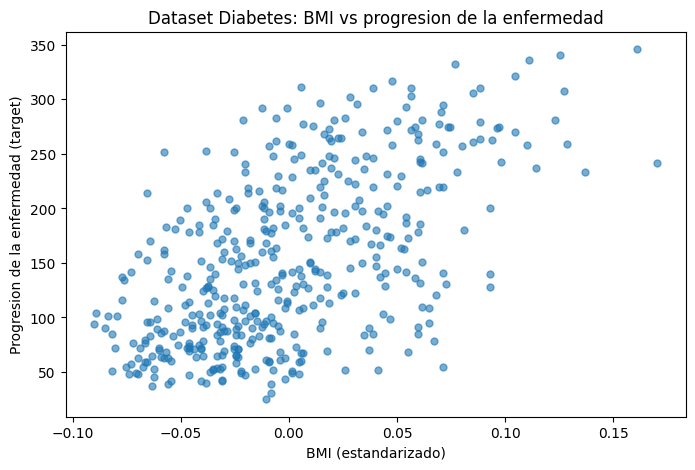

In [4]:
# Variable predictora: bmi (indice de masa corporal), ya viene estandarizada en el dataset
X_bmi = df["bmi"].values
y = df["target"].values

plt.figure(figsize=(8, 5))
plt.scatter(X_bmi, y, s=25, alpha=0.6)
plt.xlabel("BMI (estandarizado)")
plt.ylabel("Progresion de la enfermedad (target)")
plt.title("Dataset Diabetes: BMI vs progresion de la enfermedad")
plt.show()


### Paso 5: Separar en entrenamiento y prueba

**Qué hacemos:** dividimos los datos en un 80% para entrenar y un 20% para evaluar.

- Necesitamos datos que el modelo **no haya visto** (el conjunto de prueba) para saber si realmente aprendió un patrón útil, o si solo "memorizó" los datos de entrenamiento.
- `test_size=0.2` (20%) es una proporción estándar: deja suficientes datos para entrenar bien, y suficientes para evaluar de forma confiable.
- `random_state=42` asegura que la división sea siempre la misma cada vez que se ejecuta el notebook (reproducibilidad, igual que la semilla del Paso 1).


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_bmi, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape[0]} muestras | Test: {X_test.shape[0]} muestras")


Train: 353 muestras | Test: 89 muestras


### Paso 6: Probar distintos valores de $\tau$

**Qué hacemos:** ajustamos LWR con 4 valores distintos de τ (0.02, 0.1, 0.3, 1.0) y graficamos cada curva resultante.

- τ controla qué tan "local" es la regresión. Probar varios valores permite **ver con los propios ojos** el efecto:
  - τ muy chico (0.02) → la curva sigue casi cada punto individual (mucho ruido, sobreajuste).
  - τ muy grande (1.0) → la curva se vuelve casi una línea recta (se parece a una regresión lineal global, poco flexible).
- Elegimos un rango de valores que va de "muy local" a "casi global" para que la comparación sea clara.


/tmp/ipykernel_3323/3122008718.py:50: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(x_vec @ theta)


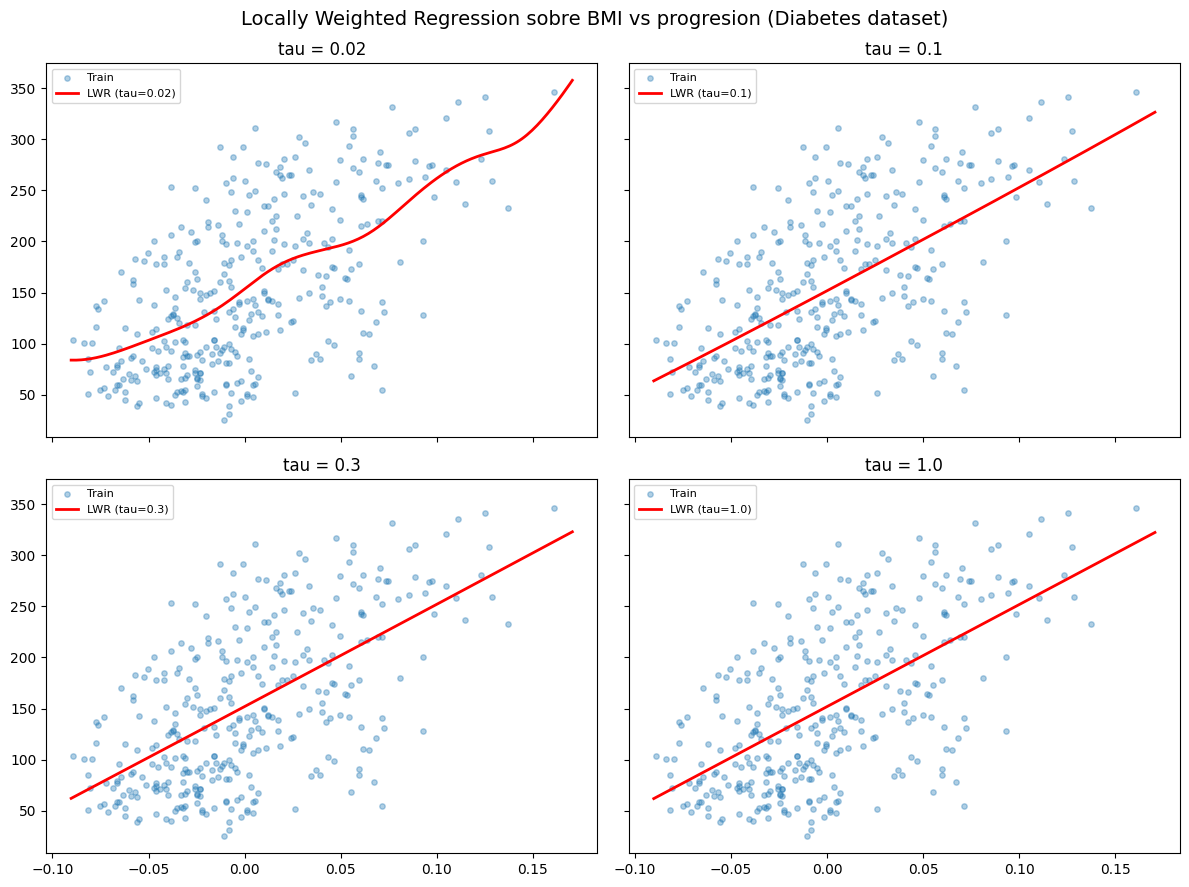

In [6]:
x_line = np.linspace(X_bmi.min(), X_bmi.max(), 200)
taus = [0.02, 0.1, 0.3, 1.0]

fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True, sharey=True)

for ax, tau in zip(axes.ravel(), taus):
    model = LocallyWeightedRegression(tau=tau)
    model.fit(X_train, y_train)
    y_line_pred = model.predict(x_line)

    ax.scatter(X_train, y_train, s=15, alpha=0.35, label="Train")
    ax.plot(x_line, y_line_pred, color="red", linewidth=2, label=f"LWR (tau={tau})")
    ax.set_title(f"tau = {tau}")
    ax.legend(fontsize=8)

plt.suptitle("Locally Weighted Regression sobre BMI vs progresion (Diabetes dataset)", fontsize=14)
plt.tight_layout()
plt.show()


### Paso 7: Comparar LWR contra una regresión lineal normal

**Qué hacemos:** entrenamos una regresión lineal clásica (`LinearRegression`) y una LWR con un τ elegido (0.15, un punto intermedio razonable según lo visto en el paso anterior), y comparamos su error sobre los datos de **prueba**.

- Usamos el conjunto de **prueba** (no el de entrenamiento) para que la comparación sea justa y refleje qué tan bien generaliza cada modelo a datos nuevos.
- Medimos con dos métricas complementarias:
  - **MSE** (error cuadrático medio): mientras más bajo, mejor; penaliza fuerte los errores grandes.
  - **R²**: qué proporción de la variación de los datos logra explicar el modelo (más cercano a 1 es mejor).
- `best_tau = 0.15` se elige a partir de lo observado visualmente en el Paso 6: ni tan chico que sobreajuste, ni tan grande que pierda flexibilidad.


In [7]:
# Regresion lineal global
lin_reg = LinearRegression()
lin_reg.fit(X_train.reshape(-1, 1), y_train)
y_pred_linear = lin_reg.predict(X_test.reshape(-1, 1))

# LWR con un tau intermedio, elegido a partir de la comparacion visual del paso anterior
best_tau = 0.15
lwr = LocallyWeightedRegression(tau=best_tau)
lwr.fit(X_train, y_train)
y_pred_lwr = lwr.predict(X_test)

mse_linear = mean_squared_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

mse_lwr = mean_squared_error(y_test, y_pred_lwr)
r2_lwr = r2_score(y_test, y_pred_lwr)

print("Regresion Lineal Global:")
print(f"  MSE = {mse_linear:.2f} | R2 = {r2_linear:.4f}")
print(f"\nLocally Weighted Regression (tau={best_tau}):")
print(f"  MSE = {mse_lwr:.2f} | R2 = {r2_lwr:.4f}")


Regresion Lineal Global:
  MSE = 4061.83 | R2 = 0.2334

Locally Weighted Regression (tau=0.15):
  MSE = 4064.94 | R2 = 0.2328


/tmp/ipykernel_3323/3122008718.py:50: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(x_vec @ theta)


### Paso 8: Visualizar ambos modelos juntos

**Qué hacemos:** graficamos la curva de la regresión lineal y la curva de LWR sobre los mismos datos.

una gráfica deja ver de forma inmediata **en qué zonas** LWR se adapta mejor a los datos que una simple línea recta, complementando los números del paso anterior.


/tmp/ipykernel_3323/3122008718.py:50: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(x_vec @ theta)


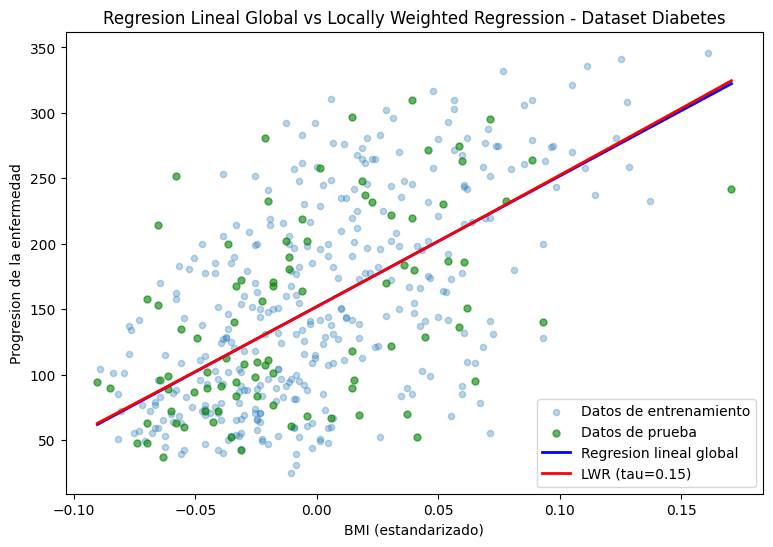

In [8]:
x_line = np.linspace(X_bmi.min(), X_bmi.max(), 200)
y_line_linear = lin_reg.predict(x_line.reshape(-1, 1))
y_line_lwr = lwr.predict(x_line)

plt.figure(figsize=(9, 6))
plt.scatter(X_train, y_train, s=20, alpha=0.3, label="Datos de entrenamiento")
plt.scatter(X_test, y_test, s=25, alpha=0.6, color="green", label="Datos de prueba")
plt.plot(x_line, y_line_linear, color="blue", linewidth=2, label="Regresion lineal global")
plt.plot(x_line, y_line_lwr, color="red", linewidth=2, label=f"LWR (tau={best_tau})")
plt.xlabel("BMI (estandarizado)")
plt.ylabel("Progresion de la enfermedad")
plt.title("Regresion Lineal Global vs Locally Weighted Regression - Dataset Diabetes")
plt.legend()
plt.show()


### Paso 9 (extra): Usar todas las variables del dataset

**Qué hacemos:** repetimos el experimento, pero ahora usando las 10 variables del dataset en lugar de solo BMI.

- Sirve para mostrar que LWR **no está limitado a una sola variable**: el kernel gaussiano se calcula igual, solo que ahora la "distancia" entre puntos se mide en un espacio de 10 dimensiones.
- Se **estandarizan** las variables con `StandardScaler` (media 0, desviación estándar 1) porque el cálculo de distancias del kernel gaussiano es sensible a la escala: si una variable tiene valores mucho más grandes que otra, dominaría el cálculo de "cercanía" aunque no sea más importante.
- Se usa un τ más grande (1.5) porque, al tener más dimensiones, los puntos en promedio están "más lejos" entre sí (maldición de la dimensionalidad), así que conviene un radio de influencia más amplio.


In [9]:
X_full = df.drop(columns=["target"]).values
y_full = df["target"].values

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42
)

# Estandarizar: pone todas las variables en la misma escala antes de medir distancias
scaler = StandardScaler()
X_train_f_s = scaler.fit_transform(X_train_f)
X_test_f_s = scaler.transform(X_test_f)

lwr_multi = LocallyWeightedRegression(tau=1.5)
lwr_multi.fit(X_train_f_s, y_train_f)
y_pred_lwr_multi = lwr_multi.predict(X_test_f_s)

lin_reg_multi = LinearRegression()
lin_reg_multi.fit(X_train_f_s, y_train_f)
y_pred_linear_multi = lin_reg_multi.predict(X_test_f_s)

print("Con las 10 variables predictoras:")
print(f"  Regresion Lineal Global -> MSE={mean_squared_error(y_test_f, y_pred_linear_multi):.2f}, R2={r2_score(y_test_f, y_pred_linear_multi):.4f}")
print(f"  Locally Weighted Reg.   -> MSE={mean_squared_error(y_test_f, y_pred_lwr_multi):.2f}, R2={r2_score(y_test_f, y_pred_lwr_multi):.4f}")


/tmp/ipykernel_3323/3122008718.py:50: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(x_vec @ theta)


Con las 10 variables predictoras:
  Regresion Lineal Global -> MSE=2900.19, R2=0.4526
  Locally Weighted Reg.   -> MSE=2581.18, R2=0.5128


## 7. Conclusiones

- Sobre el dataset **Diabetes**, LWR permite capturar posibles no linealidades en la relación entre el BMI (u otras variables) y la progresión de la enfermedad, algo que un modelo lineal global no puede representar directamente.
- El hiperparámetro $\tau$ es crítico: valores muy pequeños producen curvas muy ruidosas (sobreajuste a variaciones locales del ruido), mientras que valores grandes hacen que LWR converja hacia el comportamiento de la regresión lineal global.
- En el caso multivariable, el rendimiento de LWR depende fuertemente de la escala de las variables (por eso se estandarizan) y de la dimensionalidad del problema, dado el efecto de la maldición de la dimensionalidad.
- Se recomienda seleccionar $\tau$ mediante validación cruzada, y para datasets grandes considerar estructuras de indexación espacial (KD-Tree/Ball-Tree) para acelerar el cómputo de vecinos en tiempo de predicción.
